# Model Comparison: XGBoost vs Feed Forward Neural Network (FFNN)

## Overview

This notebook provides a systematic comparison between two interval detection models:

- **XGBoost** (gradient boosting): A tree-based ensemble method that operates on hand-crafted, session-level features extracted from heart rate and power data.
- **Feed Forward Neural Network (FFNN)**: A Feed Forward Neural Network-based approach that learns patterns directly from the time-series signal.

Both models were evaluated on the same set of athletic training sessions using a **leave-one-session-out** cross-validation strategy. Each session is held out as a test set while the remaining sessions are used for training.

### Evaluation Metrics

| Metric | Description |
|--------|-------------|
| **F_beta** | Weighted harmonic mean of precision and recall (primary metric) |
| **Precision** | Fraction of predicted intervals that are correct (fewer false positives = higher precision) |
| **Recall** | Fraction of true intervals that were detected (fewer missed intervals = higher recall) |
| **MAE (seconds)** | Mean absolute timing error between predicted and true interval boundaries |
| **False Positive Rate** | Proportion of predictions that are incorrect |
| **False Negative Rate** | Proportion of true intervals that were missed |


In [3]:
# ============================================================================
# MODEL COMPARISON ANALYSIS
# ============================================================================

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

print("="*70)
print("MODEL COMPARISON ANALYSIS: XGBoost vs FFNN")
print("="*70)

# ============================================================================
# 1. LOAD RESULTS
# ============================================================================

with open('results/xgboost_results.pkl', 'rb') as f:
    xgboost_package = pickle.load(f)

with open('results/FFNN_results.pkl', 'rb') as f:
    FFNN_package = pickle.load(f)

xgboost_results = xgboost_package['results']
FFNN_results = FFNN_package['results']

print(f"\n✓ Loaded results:")
print(f"  XGBoost: {len(xgboost_results)} sessions")
print(f"  FFNN:     {len(FFNN_results)} sessions")

# ============================================================================
# 2. CREATE COMPARISON DATAFRAME - WITH SESSION MATCHING
# ============================================================================

# Convert results lists to dictionaries keyed by session for easy matching
xgboost_dict = {res['session']: res for res in xgboost_results}
FFNN_dict = {res['session']: res for res in FFNN_results}

# Find common sessions
common_sessions = set(xgboost_dict.keys()) & set(FFNN_dict.keys())
print(f"\n✓ Found {len(common_sessions)} common sessions")

# Check for mismatches
xgb_only = set(xgboost_dict.keys()) - set(FFNN_dict.keys())
FFNN_only = set(FFNN_dict.keys()) - set(xgboost_dict.keys())

if xgb_only:
    print(f"⚠ XGBoost-only sessions: {xgb_only}")
if FFNN_only:
    print(f"⚠ FFNN-only sessions: {FFNN_only}")

comparison_data = []

for session_id in sorted(common_sessions):  # Sort for consistency
    xgb_res = xgboost_dict[session_id]
    FFNN_res = FFNN_dict[session_id]

    # Get session metadata from df
    df = xgb_res['df']
    duration_sec = len(df)
    hr_std = df['heart_rate'].std()
    hr_mean = df['heart_rate'].mean()

    # Determine sport
    sport = xgb_res.get('sport', 'unknown')
    if sport == 'unknown':
        if 'Bike' in xgb_res['athlete']:
            sport = 'biking'
        elif 'Rowing' in xgb_res['athlete']:
            sport = 'rowing'
        else:
            sport = 'rowing' if 'Athlete12' in xgb_res['athlete'] else 'biking'

    comparison_data.append({
        'session': xgb_res['session'],
        'athlete': xgb_res['athlete'],
        'sport': sport,
        'n_intervals': xgb_res['n_true'],
        'duration_sec': duration_sec,
        'duration_min': duration_sec / 60,
        'hr_std': hr_std,
        'hr_mean': hr_mean,
        'xgboost_fbeta': xgb_res['f_beta'],
        'xgboost_precision': xgb_res['precision'],
        'xgboost_recall': xgb_res['recall'],
        'FFNN_fbeta': FFNN_res['f_beta'],
        'FFNN_precision': FFNN_res['precision'],
        'FFNN_recall': FFNN_res['recall'],
        'fbeta_diff': FFNN_res['f_beta'] - xgb_res['f_beta'],
        'winner': 'FFNN' if FFNN_res['f_beta'] > xgb_res['f_beta'] else 'XGBoost' if xgb_res['f_beta'] > FFNN_res['f_beta'] else 'Tie',
    })

df_comparison = pd.DataFrame(comparison_data)

# Add complexity category
df_comparison['complexity'] = pd.cut(
    df_comparison['n_intervals'],
    bins=[0, 10, 20, 100],
    labels=['Low (≤10)', 'Medium (11-20)', 'High (>20)']
)

print(f"\n✓ Comparison dataframe created: {len(df_comparison)} sessions")

# ============================================================================
# 3. OVERALL STATISTICS
# ============================================================================

print("\n" + "="*70)
print("OVERALL PERFORMANCE")
print("="*70)

xgb_mean = df_comparison['xgboost_fbeta'].mean()
FFNN_mean = df_comparison['FFNN_fbeta'].mean()

print(f"\nMean F_beta:")
print(f"  XGBoost: {xgb_mean:.3f}")
print(f"  FFNN:     {FFNN_mean:.3f}")
print(f"  Difference: {FFNN_mean - xgb_mean:+.3f}")

print(f"\nWin/Loss/Tie:")
win_counts = df_comparison['winner'].value_counts()
for model, count in win_counts.items():
    pct = 100 * count / len(df_comparison)
    print(f"  {model}: {count} sessions ({pct:.1f}%)")

# ============================================================================
# 4. BREAKDOWN BY SPORT
# ============================================================================

print("\n" + "="*70)
print("PERFORMANCE BY SPORT")
print("="*70)

for sport in df_comparison['sport'].unique():
    sport_df = df_comparison[df_comparison['sport'] == sport]

    xgb_sport = sport_df['xgboost_fbeta'].mean()
    FFNN_sport = sport_df['FFNN_fbeta'].mean()

    print(f"\n{sport.upper()} ({len(sport_df)} sessions):")
    print(f"  XGBoost: {xgb_sport:.3f}")
    print(f"  FFNN:     {FFNN_sport:.3f}")
    print(f"  Difference: {FFNN_sport - xgb_sport:+.3f}")

    sport_wins = sport_df['winner'].value_counts()
    for model, count in sport_wins.items():
        pct = 100 * count / len(sport_df)
        print(f"  {model} wins: {count} ({pct:.1f}%)")

# ============================================================================
# 5. BREAKDOWN BY COMPLEXITY
# ============================================================================

print("\n" + "="*70)
print("PERFORMANCE BY SESSION COMPLEXITY")
print("="*70)

for complexity in ['Low (≤10)', 'Medium (11-20)', 'High (>20)']:
    comp_df = df_comparison[df_comparison['complexity'] == complexity]

    if len(comp_df) == 0:
        continue

    xgb_comp = comp_df['xgboost_fbeta'].mean()
    FFNN_comp = comp_df['FFNN_fbeta'].mean()

    print(f"\n{complexity} INTERVALS ({len(comp_df)} sessions):")
    print(f"  XGBoost: {xgb_comp:.3f}")
    print(f"  FFNN:     {FFNN_comp:.3f}")
    print(f"  Difference: {FFNN_comp - xgb_comp:+.3f}")

    comp_wins = comp_df['winner'].value_counts()
    for model, count in comp_wins.items():
        pct = 100 * count / len(comp_df)
        print(f"  {model} wins: {count} ({pct:.1f}%)")

# ============================================================================
# 6. SESSION-BY-SESSION TABLE
# ============================================================================

print("\n" + "="*70)
print("SESSION-BY-SESSION COMPARISON")
print("="*70)

# Sort by absolute difference
df_sorted = df_comparison.sort_values('fbeta_diff', key=abs, ascending=False)

print(f"\n{'Session':<40} {'Sport':<8} {'Int':<4} {'XGB':<6} {'FFNN':<6} {'Diff':<7} {'Winner':<10}")
print("-" * 90)

for _, row in df_sorted.iterrows():
    session_short = row['session'][:37] + "..." if len(row['session']) > 40 else row['session']
    print(f"{session_short:<40} {row['sport']:<8} {row['n_intervals']:<4} "
          f"{row['xgboost_fbeta']:<6.3f} {row['FFNN_fbeta']:<6.3f} "
          f"{row['fbeta_diff']:+7.3f} {row['winner']:<10}")

# ============================================================================
# 7. VISUALIZATIONS
# ============================================================================

print("\n" + "="*70)
print("GENERATING VISUALIZATIONS")
print("="*70)

# Plot 1: Scatter plot
fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(df_comparison['xgboost_fbeta'], df_comparison['FFNN_fbeta'],
           s=100, alpha=0.6, c='steelblue', edgecolors='black')
ax.plot([0, 1], [0, 1], 'r--', label='Equal performance', linewidth=2)
ax.set_xlabel('XGBoost F_beta', fontsize=14)
ax.set_ylabel('FFNN F_beta', fontsize=14)
ax.set_title('XGBoost vs FFNN Performance (Session-by-Session)', fontsize=16)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig('results/comparison_scatter.png', dpi=300, bbox_inches='tight')
print("✓ Saved: results/comparison_scatter.png")
plt.close()

# Plot 2: Bar chart by category
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# By sport
sport_stats = df_comparison.groupby('sport')[['xgboost_fbeta', 'FFNN_fbeta']].mean()
sport_stats.plot(kind='bar', ax=axes[0], color=['#1f77b4', '#ff7f0e'])
axes[0].set_title('Average F_beta by Sport', fontsize=14)
axes[0].set_ylabel('F_beta', fontsize=12)
axes[0].set_xlabel('Sport', fontsize=12)
axes[0].legend(['XGBoost', 'FFNN'], fontsize=11)
axes[0].set_xticklabels(sport_stats.index, rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

# By complexity
comp_stats = df_comparison.groupby('complexity')[['xgboost_fbeta', 'FFNN_fbeta']].mean()
comp_stats.plot(kind='bar', ax=axes[1], color=['#1f77b4', '#ff7f0e'])
axes[1].set_title('Average F_beta by Complexity', fontsize=14)
axes[1].set_ylabel('F_beta', fontsize=12)
axes[1].set_xlabel('Number of Intervals', fontsize=12)
axes[1].legend(['XGBoost', 'FFNN'], fontsize=11)
axes[1].set_xticklabels(comp_stats.index, rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('results/comparison_categories.png', dpi=300, bbox_inches='tight')
print("✓ Saved: results/comparison_categories.png")
plt.close()

# Plot 3: Difference heatmap
fig, ax = plt.subplots(figsize=(12, 8))
pivot = df_comparison.pivot_table(
    values='fbeta_diff',
    index='complexity',
    columns='sport',
    aggfunc='mean'
)
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            cbar_kws={'label': 'FFNN - XGBoost F_beta'}, ax=ax)
ax.set_title('Performance Difference (FFNN - XGBoost) by Category', fontsize=14)
plt.tight_layout()
plt.savefig('results/comparison_heatmap.png', dpi=300, bbox_inches='tight')
print("✓ Saved: results/comparison_heatmap.png")
plt.close()

# ============================================================================
# 8. SAVE COMPARISON TABLE
# ============================================================================

df_comparison.to_csv('results/comparison_table.csv', index=False)
print("\n✓ Saved: results/comparison_table.csv")

print("\n" + "="*70)
print("ANALYSIS COMPLETE")
print("="*70)

MODEL COMPARISON ANALYSIS: XGBoost vs FFNN

✓ Loaded results:
  XGBoost: 18 sessions
  FFNN:     18 sessions

✓ Found 18 common sessions

✓ Comparison dataframe created: 18 sessions

OVERALL PERFORMANCE

Mean F_beta:
  XGBoost: 0.697
  FFNN:     0.714
  Difference: +0.016

Win/Loss/Tie:
  FFNN: 9 sessions (50.0%)
  XGBoost: 6 sessions (33.3%)
  Tie: 3 sessions (16.7%)

PERFORMANCE BY SPORT

BIKING (6 sessions):
  XGBoost: 0.587
  FFNN:     0.661
  Difference: +0.074
  FFNN wins: 4 (66.7%)
  XGBoost wins: 2 (33.3%)

ROWING (12 sessions):
  XGBoost: 0.753
  FFNN:     0.740
  Difference: -0.013
  FFNN wins: 5 (41.7%)
  XGBoost wins: 4 (33.3%)
  Tie wins: 3 (25.0%)

PERFORMANCE BY SESSION COMPLEXITY

Low (≤10) INTERVALS (8 sessions):
  XGBoost: 0.731
  FFNN:     0.705
  Difference: -0.026
  XGBoost wins: 4 (50.0%)
  FFNN wins: 3 (37.5%)
  Tie wins: 1 (12.5%)

Medium (11-20) INTERVALS (6 sessions):
  XGBoost: 0.731
  FFNN:     0.759
  Difference: +0.028
  FFNN wins: 3 (50.0%)
  Tie wins: 2 

C:\Users\katha\AppData\Local\Temp\ipykernel_20468\780643968.py:241: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  comp_stats = df_comparison.groupby('complexity')[['xgboost_fbeta', 'FFNN_fbeta']].mean()


✓ Saved: results/comparison_categories.png


C:\Users\katha\AppData\Local\Temp\ipykernel_20468\780643968.py:257: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df_comparison.pivot_table(


✓ Saved: results/comparison_heatmap.png

✓ Saved: results/comparison_table.csv

ANALYSIS COMPLETE


## Interpretation: Overall Comparison

### What to look for in the results above

- **Mean F_beta**: The average detection quality across all sessions. A higher value means the model is better at correctly identifying interval boundaries while avoiding false alarms. The model with the higher mean F_beta is the overall better performer.

- **Win/Loss/Tie**: Shows how often each model outperformed the other on individual sessions. Even if one model has a higher average F_beta, the other may still win on specific session types.

- **Breakdown by Sport**: Performance may differ between biking and rowing due to differences in heart rate dynamics. Biking sessions often have sharper, more defined heart rate responses to interval changes, while rowing patterns can be more gradual.

- **Breakdown by Complexity**: Sessions with fewer intervals (Low) tend to be easier to detect. As the number of intervals increases (High), models face more opportunities for both correct detections and errors. A model that maintains performance on high-complexity sessions is more robust.

- **Session-by-session table**: Sorted by the largest absolute performance difference, this table highlights where the models disagree most. These sessions are the most informative for understanding model strengths and weaknesses.

- **Scatter plot**: Points above the diagonal line indicate sessions where FFNN outperformed XGBoost; points below indicate the opposite. Clustering near the diagonal suggests similar overall performance.

- **Heatmap**: Shows which sport-complexity combinations favor which model. Positive values (green) indicate FFNN advantage; negative values (red) indicate XGBoost advantage.


## Summary Tables

In [7]:
# ============================================================================
# SUMMARY TABLES
# ============================================================================

# Add MAE to df_comparison for table use
df_comparison['xgboost_mae'] = df_comparison['session'].apply(
    lambda s: xgboost_dict[s]['mean_error_sec'])
df_comparison['FFNN_mae'] = df_comparison['session'].apply(
    lambda s: FFNN_dict[s]['mean_error_sec'])

metrics = ['fbeta', 'precision', 'recall', 'mae']
xgb_cols = ['xgboost_fbeta', 'xgboost_precision', 'xgboost_recall', 'xgboost_mae']
FFNN_cols = ['FFNN_fbeta', 'FFNN_precision', 'FFNN_recall', 'FFNN_mae']

# ── Table 1: Overall metrics per model ──
print("=" * 60)
print("TABLE 1: Overall Metrics per Model")
print("=" * 60)

overall = pd.DataFrame({
    'Metric': ['F_beta', 'Precision', 'Recall', 'MAE (sec)'],
    'XGBoost': [df_comparison[c].mean() for c in xgb_cols],
    'FFNN':      [df_comparison[c].mean() for c in FFNN_cols],
})
overall['Difference (FFNN - XGB)'] = overall['FFNN'] - overall['XGBoost']
overall = overall.set_index('Metric')
overall = overall.round(3)
display(overall)

# ── Table 2: Metrics per model per sport ──
print("\n" + "=" * 60)
print("TABLE 2: Metrics per Model per Sport")
print("=" * 60)

rows = []
for sport in sorted(df_comparison['sport'].unique()):
    sdf = df_comparison[df_comparison['sport'] == sport]
    for metric_name, xc, nc in zip(
        ['F_beta', 'Precision', 'Recall', 'MAE (sec)'],
        xgb_cols, FFNN_cols
    ):
        rows.append({
            'Sport': sport,
            'Metric': metric_name,
            'XGBoost': round(sdf[xc].mean(), 3),
            'FFNN': round(sdf[nc].mean(), 3),
            'Diff (FFNN-XGB)': round(sdf[nc].mean() - sdf[xc].mean(), 3),
            'N Sessions': len(sdf),
        })

df_sport_table = pd.DataFrame(rows).set_index(['Sport', 'Metric'])
display(df_sport_table)

# ── Table 3: Metrics per model per complexity ──
print("\n" + "=" * 60)
print("TABLE 3: Metrics per Model per Complexity")
print("=" * 60)

rows = []
for comp in ['Low (≤10)', 'Medium (11-20)', 'High (>20)']:
    cdf = df_comparison[df_comparison['complexity'] == comp]
    if len(cdf) == 0:
        continue
    for metric_name, xc, nc in zip(
        ['F_beta', 'Precision', 'Recall', 'MAE (sec)'],
        xgb_cols, FFNN_cols
    ):
        rows.append({
            'Complexity': comp,
            'Metric': metric_name,
            'XGBoost': round(cdf[xc].mean(), 3),
            'FFNN': round(cdf[nc].mean(), 3),
            'Diff (FFNN-XGB)': round(cdf[nc].mean() - cdf[xc].mean(), 3),
            'N Sessions': len(cdf),
        })

df_comp_table = pd.DataFrame(rows).set_index(['Complexity', 'Metric'])
display(df_comp_table)

# ── Table 4: Win/Loss per sport and complexity ──
print("\n" + "=" * 60)
print("TABLE 4: Win Counts (based on F_beta)")
print("=" * 60)

win_pivot = df_comparison.pivot_table(
    index='sport',
    columns='winner',
    values='session',
    aggfunc='count',
    fill_value=0
)
# Ensure all columns present
for col in ['XGBoost', 'FFNN', 'Tie']:
    if col not in win_pivot.columns:
        win_pivot[col] = 0
win_pivot = win_pivot[['XGBoost', 'FFNN', 'Tie']]
win_pivot['Total'] = win_pivot.sum(axis=1)
print("\nBy Sport:")
display(win_pivot)

win_pivot_comp = df_comparison.pivot_table(
    index='complexity',
    columns='winner',
    values='session',
    aggfunc='count',
    fill_value=0
)
for col in ['XGBoost', 'FFNN', 'Tie']:
    if col not in win_pivot_comp.columns:
        win_pivot_comp[col] = 0
win_pivot_comp = win_pivot_comp[['XGBoost', 'FFNN', 'Tie']]
win_pivot_comp['Total'] = win_pivot_comp.sum(axis=1)
print("\nBy Complexity:")
display(win_pivot_comp)

TABLE 1: Overall Metrics per Model


,XGBoost,FFNN,Difference (FFNN - XGB)
Metric,,,
F_beta,0.6973,0.7137,0.0164
Precision,0.6991,0.7153,0.0162
Recall,0.6966,0.7131,0.0164
MAE (sec),18.3013,18.3398,0.0386



TABLE 2: Metrics per Model per Sport


XGBoost     FFNN  Diff (FFNN-XGB)  N Sessions
Sport  Metric                                                  
biking F_beta      0.5865   0.6608           0.0743           6
       Precision   0.5919   0.6633           0.0714           6
       Recall      0.5846   0.6601           0.0756           6
       MAE (sec)  22.5531  20.4183          -2.1348           6
rowing F_beta      0.7527   0.7401          -0.0126          12
       Precision   0.7527   0.7413          -0.0114          12
       Recall      0.7527   0.7396          -0.0131          12
       MAE (sec)  16.1754  17.3006           1.1252          12


TABLE 3: Metrics per Model per Complexity


...


TABLE 4: Win Counts (based on F_beta)

By Sport:


winner,XGBoost,FFNN,Tie,Total
sport,,,,
biking,2,4,0,6
rowing,4,5,3,12



By Complexity:


C:\Users\katha\AppData\Local\Temp\ipykernel_20468\3698931712.py:101: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  win_pivot_comp = df_comparison.pivot_table(


winner,XGBoost,FFNN,Tie,Total
complexity,,,,
Low (≤10),4,3,1,8
Medium (11-20),1,3,2,6
High (>20),1,3,0,4


In [5]:
# ============================================================================
# ADDITIONAL COMPARISON METRICS
# ============================================================================

print("\n" + "="*70)
print("DETAILED METRICS COMPARISON")
print("="*70)

# 1. TIMING ACCURACY
print("\n1. TIMING ACCURACY (Mean Absolute Error in seconds)")
print("-" * 70)
print(f"{'Session':<40} {'XGB MAE':<10} {'FFNN MAE':<10} {'Difference':<12}")
print("-" * 70)

for _, row in df_comparison.head(10).iterrows():
    session_short = row['session'][:37] + "..."
    xgb_mae = xgboost_dict[row['session']]['mean_error_sec']
    FFNN_mae = FFNN_dict[row['session']]['mean_error_sec']
    diff = FFNN_mae - xgb_mae
    print(f"{session_short:<40} {xgb_mae:<10.1f} {FFNN_mae:<10.1f} {diff:+12.1f}")

# 2. FALSE POSITIVE/NEGATIVE ANALYSIS
print("\n2. FALSE POSITIVE & FALSE NEGATIVE RATES")
print("-" * 70)

comparison_data_detailed = []

for session_id in sorted(common_sessions):
    xgb_res = xgboost_dict[session_id]
    FFNN_res = FFNN_dict[session_id]

    # Calculate FP and FN
    xgb_tp = xgb_res['recall'] * xgb_res['n_true']
    xgb_fp = xgb_res['n_pred'] - xgb_tp
    xgb_fn = xgb_res['n_true'] - xgb_tp

    FFNN_tp = FFNN_res['recall'] * FFNN_res['n_true']
    FFNN_fp = FFNN_res['n_pred'] - FFNN_tp
    FFNN_fn = FFNN_res['n_true'] - FFNN_tp

    comparison_data_detailed.append({
        'session': session_id,
        'n_true': xgb_res['n_true'],
        'xgb_fp': xgb_fp,
        'xgb_fn': xgb_fn,
        'FFNN_fp': FFNN_fp,
        'FFNN_fn': FFNN_fn,
        'xgb_fp_rate': xgb_fp / xgb_res['n_pred'] if xgb_res['n_pred'] > 0 else 0,
        'FFNN_fp_rate': FFNN_fp / FFNN_res['n_pred'] if FFNN_res['n_pred'] > 0 else 0,
        'xgb_fn_rate': xgb_fn / xgb_res['n_true'] if xgb_res['n_true'] > 0 else 0,
        'FFNN_fn_rate': FFNN_fn / FFNN_res['n_true'] if FFNN_res['n_true'] > 0 else 0,
    })

df_detailed = pd.DataFrame(comparison_data_detailed)

print(f"\nAverage False Positive Rate:")
print(f"  XGBoost: {df_detailed['xgb_fp_rate'].mean():.3f}")
print(f"  FFNN:     {df_detailed['FFNN_fp_rate'].mean():.3f}")

print(f"\nAverage False Negative Rate:")
print(f"  XGBoost: {df_detailed['xgb_fn_rate'].mean():.3f}")
print(f"  FFNN:     {df_detailed['FFNN_fn_rate'].mean():.3f}")

# 3. CONSISTENCY (Standard Deviation)
print("\n3. MODEL CONSISTENCY (Performance Variability)")
print("-" * 70)
print(f"  XGBoost std dev: {df_comparison['xgboost_fbeta'].std():.3f}")
print(f"  FFNN std dev:     {df_comparison['FFNN_fbeta'].std():.3f}")
print(f"  → {'XGBoost is more consistent' if df_comparison['xgboost_fbeta'].std() < df_comparison['FFNN_fbeta'].std() else 'FFNN is more consistent'}")

# 4. FAILURE ANALYSIS (F_beta < 0.5)
print("\n4. FAILURE RATE (F_beta < 0.5)")
print("-" * 70)
xgb_failures = (df_comparison['xgboost_fbeta'] < 0.5).sum()
FFNN_failures = (df_comparison['FFNN_fbeta'] < 0.5).sum()
print(f"  XGBoost failures: {xgb_failures}/{len(df_comparison)} ({100*xgb_failures/len(df_comparison):.1f}%)")
print(f"  FFNN failures:     {FFNN_failures}/{len(df_comparison)} ({100*FFNN_failures/len(df_comparison):.1f}%)")


DETAILED METRICS COMPARISON

1. TIMING ACCURACY (Mean Absolute Error in seconds)
----------------------------------------------------------------------
Session                                  XGB MAE    FFNN MAE   Difference  
----------------------------------------------------------------------
10283878603_Zwift__HIT__HIT_EB_5x3_mi... 22.0       46.6              +24.6
11783093951_4x2000_sub8...               28.0       8.2               -19.8
11846980624_Platt_...                    8.9        36.4              +27.5
11962243206_Wundmanagement...            4.0        3.7                -0.3
12036692734_Exhausted...                 5.1        11.7               +6.6
12069656901_Schwitzen_im_Sitzen...       6.9        11.4               +4.6
12846436186_Synchronflug...              1.7        0.7                -1.0
13363782092_Zwift__Aerobic_Mixup_in_N... 66.1       11.5              -54.6
13557212506_Zwift__HIT__HIT_EB_7x2_mi... 6.7        8.5                +1.8
13601462878_Zehn

## Interpretation: Detailed Metrics

### Timing Accuracy (MAE)

The Mean Absolute Error in seconds measures how precisely each model places interval boundaries relative to the ground truth. A lower MAE indicates that predicted boundaries are closer to the actual transitions. This is important because even a correctly detected interval is less useful if its boundaries are significantly shifted in time.

### False Positive and False Negative Rates

These two error types have different practical implications:

- **False Positives** (predicting an interval that doesn't exist): These create unnecessary noise for the user. A high false positive rate means the model is "over-detecting," which increases the manual review burden.
- **False Negatives** (missing a real interval): These are generally more costly, as missed intervals represent lost training data. A high false negative rate means the model is "under-detecting."

The trade-off between these two error types is captured by precision (inversely related to false positives) and recall (inversely related to false negatives).

### Model Consistency

The standard deviation of F_beta across sessions indicates how predictable a model's performance is. A model with lower standard deviation is more consistent -- the user can expect similar quality regardless of the session. A model with higher variability might perform excellently on some sessions but poorly on others.

### Failure Rate

Sessions with F_beta < 0.5 represent cases where the model's predictions are more wrong than right. A lower failure rate indicates a model that is more reliable across diverse session types. Identifying which sessions cause failures can reveal systematic weaknesses (e.g., a model that struggles with specific sport types or complexity levels).



GENERATING PER-SESSION COMPARISON VISUALIZATIONS


C:\Users\katha\AppData\Local\Temp\ipykernel_20468\4165245082.py:154: UserWarning: Glyph 128692 (\N{BICYCLIST}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\katha\AppData\Local\Temp\ipykernel_20468\4165245082.py:154: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\katha\AppData\Local\Temp\ipykernel_20468\4165245082.py:154: UserWarning: Glyph 128675 (\N{ROWBOAT}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\katha\AppData\Local\Temp\ipykernel_20468\4165245082.py:155: UserWarning: Glyph 128692 (\N{BICYCLIST}) missing from font(s) Arial.
  plt.savefig('results/per_session_comparison.png', dpi=300, bbox_inches='tight')
C:\Users\katha\AppData\Local\Temp\ipykernel_20468\4165245082.py:155: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  plt.savefig('results/per_session_comparison.png', dpi=300, bbox_inches='tight')
C:\Users\katha\AppData\Local\Temp\ipykernel_20468\4165245082.py:155: UserWarning: Glyp


✓ Saved: results/per_session_comparison.png
  (18 sessions visualized)

Generating individual session plots...


C:\Users\katha\AppData\Local\Temp\ipykernel_20468\4165245082.py:267: UserWarning: Glyph 128692 (\N{BICYCLIST}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\katha\AppData\Local\Temp\ipykernel_20468\4165245082.py:267: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\katha\AppData\Local\Temp\ipykernel_20468\4165245082.py:272: UserWarning: Glyph 128692 (\N{BICYCLIST}) missing from font(s) Arial.
  plt.savefig(f'results/individual_sessions/{filename}', dpi=200, bbox_inches='tight')
C:\Users\katha\AppData\Local\Temp\ipykernel_20468\4165245082.py:272: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  plt.savefig(f'results/individual_sessions/{filename}', dpi=200, bbox_inches='tight')
C:\Users\katha\AppData\Local\Temp\ipykernel_20468\4165245082.py:267: UserWarning: Glyph 128675 (\N{ROWBOAT}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\katha\AppData\Local\Temp\ipykernel_20468\4165245082.py:272: UserWar

✓ Saved 18 individual session plots to results/individual_sessions/

VISUALIZATION COMPLETE

Legend:
  🟢 Green solid line  = Ground Truth intervals
  🔵 Blue X           = XGBoost predictions
  🟠 Orange circle    = FFNN predictions
  📊 Agreement %      = How many predictions match (within 3 sec)
  🏆 Winner          = Model with higher F_beta score


C:\Users\katha\OneDrive - Microsoft 365 der Universität Wien\Masterarbeit\Codes\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128692 (\N{BICYCLIST}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\katha\OneDrive - Microsoft 365 der Universität Wien\Masterarbeit\Codes\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\katha\OneDrive - Microsoft 365 der Universität Wien\Masterarbeit\Codes\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128675 (\N{ROWBOAT}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


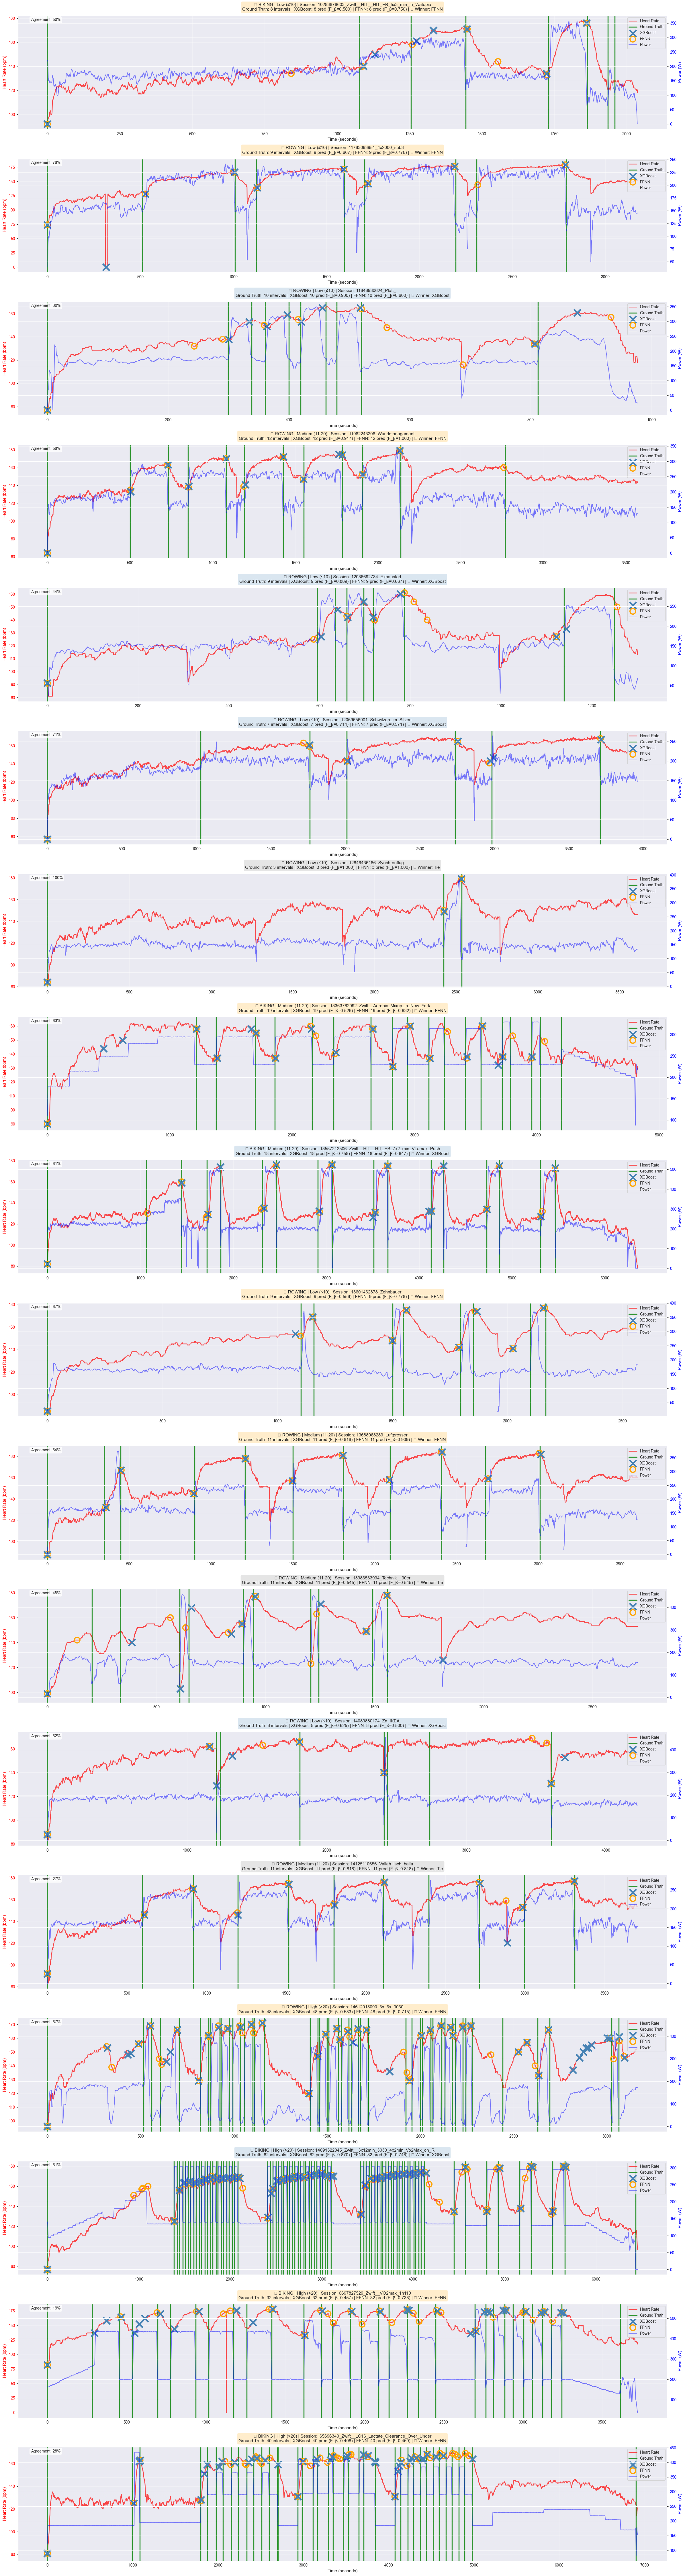

In [12]:
# ============================================================================
# PER-SESSION VISUALIZATION: XGBoost vs FFNN
# ============================================================================

print("\n" + "="*70)
print("GENERATING PER-SESSION COMPARISON VISUALIZATIONS")
print("="*70)

# Get common sessions in sorted order
common_session_ids = sorted(common_sessions)

n_sessions = len(common_session_ids)
fig, axes = plt.subplots(n_sessions, 1, figsize=(24, 5*n_sessions))

# Handle case where there's only one session
if n_sessions == 1:
    axes = [axes]

for idx, session_id in enumerate(common_session_ids):
    xgb_res = xgboost_dict[session_id]
    FFNN_res = FFNN_dict[session_id]

    # Get data
    df = xgb_res['df']
    y_true = xgb_res['y_true']
    xgb_pred = xgb_res['y_pred']
    FFNN_pred = FFNN_res['y_pred']

    hr_values = df['heart_rate'].values

    # Determine sport and complexity
    sport = xgb_res.get('sport', 'unknown')
    if sport == 'unknown':
        if 'Bike' in xgb_res['athlete'] or 'Zwift' in session_id:
            sport = 'biking'
        else:
            sport = 'rowing'

    n_intervals = xgb_res['n_true']
    if n_intervals <= 10:
        complexity = 'Low (≤10)'
    elif n_intervals <= 20:
        complexity = 'Medium (11-20)'
    else:
        complexity = 'High (>20)'

    # Determine winner
    if xgb_res['f_beta'] > FFNN_res['f_beta']:
        winner = 'XGBoost'
        winner_color = 'steelblue'
    elif FFNN_res['f_beta'] > xgb_res['f_beta']:
        winner = 'FFNN'
        winner_color = 'orange'
    else:
        winner = 'Tie'
        winner_color = 'gray'

    # Create twin axis for power
    ax1 = axes[idx]
    ax2 = ax1.twinx()

    # Plot heart rate on left axis (RED)
    ax1.plot(hr_values, label='Heart Rate', color='red', alpha=0.7, linewidth=2)

    # Plot power on right axis (BLUE)
    if 'power' in df.columns:
        power_values = df['power'].values
        ax2.plot(power_values, label='Power', color='blue', alpha=0.5, linewidth=1.5)
        ax2.set_ylabel('Power (W)', fontsize=11, color='blue')
        ax2.tick_params(axis='y', labelcolor='blue')

    # Get change points
    gt_cps = np.where(y_true == 1)[0]
    xgb_cps = np.where(xgb_pred == 1)[0]
    FFNN_cps = np.where(FFNN_pred == 1)[0]

    # Mark ground truth change points with GREEN vertical solid lines
    for cp in gt_cps:
        if cp < len(hr_values):
            ax1.axvline(x=cp, color='green', linestyle='-', linewidth=2.5,
                       alpha=0.8, zorder=3, label='Ground Truth' if cp == gt_cps[0] else '')

    # Mark XGBoost predictions with BLUE X
    for cp in xgb_cps:
        if cp < len(hr_values):
            ax1.scatter(cp, hr_values[cp], marker='x', s=300, color='steelblue',
                       linewidths=4, zorder=5, label='XGBoost' if cp == xgb_cps[0] else '')

    # Mark FFNN predictions with ORANGE circle
    for cp in FFNN_cps:
        if cp < len(hr_values):
            ax1.scatter(cp, hr_values[cp], marker='o', s=200,
                       facecolors='none', edgecolors='orange',
                       linewidths=3, zorder=4, label='FFNN' if cp == FFNN_cps[0] else '')

    # Enhanced title with sport, complexity, and winner
    sport_emoji = '🚴' if sport == 'biking' else '🚣'
    title_text = (
        f"{sport_emoji} {sport.upper()} | {complexity} | Session: {session_id[:50]}\n"
        f"Ground Truth: {xgb_res['n_true']} intervals | "
        f"XGBoost: {xgb_res['n_pred']} pred (F_β={xgb_res['f_beta']:.3f}) | "
        f"FFNN: {FFNN_res['n_pred']} pred (F_β={FFNN_res['f_beta']:.3f}) | "
        f"🏆 Winner: {winner}"
    )

    ax1.set_title(title_text, fontsize=11, pad=12,
                  bbox=dict(boxstyle='round', facecolor=winner_color, alpha=0.2))

    # Calculate agreement
    agreement_count = 0
    for xgb_cp in xgb_cps:
        for FFNN_cp in FFNN_cps:
            if abs(xgb_cp - FFNN_cp) <= 3:  # Within 3 seconds
                agreement_count += 1
                break

    total_predictions = max(len(xgb_cps), len(FFNN_cps))
    agreement_pct = (agreement_count / total_predictions * 100) if total_predictions > 0 else 0

    # Add agreement text box
    agreement_text = f"Agreement: {agreement_pct:.0f}%"
    ax1.text(0.02, 0.98, agreement_text,
             transform=ax1.transAxes, fontsize=10,
             verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    ax1.set_ylabel('Heart Rate (bpm)', fontsize=11, color='red')
    ax1.set_xlabel('Time (seconds)', fontsize=11)
    ax1.tick_params(axis='y', labelcolor='red')
    ax1.grid(True, alpha=0.3)

    # Combine legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    if 'power' in df.columns:
        lines2, labels2 = ax2.get_legend_handles_labels()
        # Remove duplicates
        unique_labels = []
        unique_lines = []
        for line, label in zip(lines1 + lines2, labels1 + labels2):
            if label not in unique_labels:
                unique_labels.append(label)
                unique_lines.append(line)
        ax1.legend(unique_lines, unique_labels, loc='upper right', fontsize=10)
    else:
        # Remove duplicates
        unique_labels = []
        unique_lines = []
        for line, label in zip(lines1, labels1):
            if label not in unique_labels:
                unique_labels.append(label)
                unique_lines.append(line)
        ax1.legend(unique_lines, unique_labels, loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig('results/per_session_comparison.png', dpi=300, bbox_inches='tight')
print(f"\n✓ Saved: results/per_session_comparison.png")
print(f"  ({n_sessions} sessions visualized)")

# Also save individual session plots for detailed inspection
print("\nGenerating individual session plots...")
import os
os.makedirs('results/individual_sessions', exist_ok=True)

for idx, session_id in enumerate(common_session_ids):
    xgb_res = xgboost_dict[session_id]
    FFNN_res = FFNN_dict[session_id]

    df = xgb_res['df']
    y_true = xgb_res['y_true']
    xgb_pred = xgb_res['y_pred']
    FFNN_pred = FFNN_res['y_pred']
    hr_values = df['heart_rate'].values

    # Determine sport and complexity
    sport = xgb_res.get('sport', 'unknown')
    if sport == 'unknown':
        if 'Bike' in xgb_res['athlete'] or 'Zwift' in session_id:
            sport = 'biking'
        else:
            sport = 'rowing'

    n_intervals = xgb_res['n_true']
    if n_intervals <= 10:
        complexity = 'Low'
    elif n_intervals <= 20:
        complexity = 'Med'
    else:
        complexity = 'High'

    winner = 'XGB' if xgb_res['f_beta'] > FFNN_res['f_beta'] else 'FFNN' if FFNN_res['f_beta'] > xgb_res['f_beta'] else 'Tie'
    winner_color = 'steelblue' if winner == 'XGB' else 'orange' if winner == 'FFNN' else 'gray'

    # Create figure
    fig, ax1 = plt.subplots(1, 1, figsize=(20, 6))
    ax2 = ax1.twinx()

    # Plot heart rate
    ax1.plot(hr_values, label='Heart Rate', color='red', alpha=0.7, linewidth=2)

    # Plot power
    if 'power' in df.columns:
        power_values = df['power'].values
        ax2.plot(power_values, label='Power', color='blue', alpha=0.5, linewidth=1.5)
        ax2.set_ylabel('Power (W)', fontsize=12, color='blue')
        ax2.tick_params(axis='y', labelcolor='blue')

    # Get change points
    gt_cps = np.where(y_true == 1)[0]
    xgb_cps = np.where(xgb_pred == 1)[0]
    FFNN_cps = np.where(FFNN_pred == 1)[0]

    # Mark ground truth
    for cp in gt_cps:
        if cp < len(hr_values):
            ax1.axvline(x=cp, color='green', linestyle='-', linewidth=2.5,
                       alpha=0.8, zorder=3, label='Ground Truth' if cp == gt_cps[0] else '')

    # Mark XGBoost
    for cp in xgb_cps:
        if cp < len(hr_values):
            ax1.scatter(cp, hr_values[cp], marker='x', s=300, color='steelblue',
                       linewidths=4, zorder=5, label='XGBoost' if cp == xgb_cps[0] else '')

    # Mark FFNN
    for cp in FFNN_cps:
        if cp < len(hr_values):
            ax1.scatter(cp, hr_values[cp], marker='o', s=200,
                       facecolors='none', edgecolors='orange',
                       linewidths=3, zorder=4, label='FFNN' if cp == FFNN_cps[0] else '')

    # Title
    sport_emoji = '🚴' if sport == 'biking' else '🚣'
    title_text = (
        f"{sport_emoji} {sport.upper()} | Complexity: {complexity} | {session_id}\n"
        f"GT: {xgb_res['n_true']} | XGBoost: {xgb_res['n_pred']} (F_β={xgb_res['f_beta']:.3f}) | "
        f"FFNN: {FFNN_res['n_pred']} (F_β={FFNN_res['f_beta']:.3f}) | 🏆 {winner}"
    )

    ax1.set_title(title_text, fontsize=13, pad=15,
                  bbox=dict(boxstyle='round', facecolor=winner_color, alpha=0.2))

    ax1.set_ylabel('Heart Rate (bpm)', fontsize=12, color='red')
    ax1.set_xlabel('Time (seconds)', fontsize=12)
    ax1.tick_params(axis='y', labelcolor='red')
    ax1.grid(True, alpha=0.3)

    # Legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    if 'power' in df.columns:
        lines2, labels2 = ax2.get_legend_handles_labels()
        unique_labels = []
        unique_lines = []
        for line, label in zip(lines1 + lines2, labels1 + labels2):
            if label not in unique_labels:
                unique_labels.append(label)
                unique_lines.append(line)
        ax1.legend(unique_lines, unique_labels, loc='upper right', fontsize=11)
    else:
        unique_labels = []
        unique_lines = []
        for line, label in zip(lines1, labels1):
            if label not in unique_labels:
                unique_labels.append(label)
                unique_lines.append(line)
        ax1.legend(unique_lines, unique_labels, loc='upper right', fontsize=11)

    plt.tight_layout()

    # Clean filename
    safe_session = session_id.replace('/', '_').replace('\\', '_')[:100]
    filename = f"{idx+1:02d}_{sport}_{complexity}_{winner}_{safe_session}.png"
    plt.savefig(f'results/individual_sessions/{filename}', dpi=200, bbox_inches='tight')
    plt.close()

print(f"✓ Saved {n_sessions} individual session plots to results/individual_sessions/")

print("\n" + "="*70)
print("VISUALIZATION COMPLETE")
print("="*70)
print("\nLegend:")
print("  🟢 Green solid line  = Ground Truth intervals")
print("  🔵 Blue X           = XGBoost predictions")
print("  🟠 Orange circle    = FFNN predictions")
print("  📊 Agreement %      = How many predictions match (within 3 sec)")
print("  🏆 Winner          = Model with higher F_beta score")

## Interpretation: Per-Session Visualizations

### Reading the Plots

Each subplot shows a single training session with the following elements:

- **Red line (left axis)**: Heart rate over time. The characteristic rises and drops correspond to work and rest intervals.
- **Blue line (right axis)**: Power output over time (if available). Sharp power transitions often align with interval boundaries.
- **Green vertical lines**: Ground truth interval boundaries as annotated by the athlete/coach.
- **Blue X markers**: XGBoost's predicted interval boundaries.
- **Orange circle markers**: FFNN's predicted interval boundaries.

### What the Agreement Percentage Tells Us

The agreement percentage in the top-left corner of each plot measures how many predictions the two models share (within a 3-second tolerance). A high agreement suggests both models are detecting the same patterns, increasing confidence in those predictions. Low agreement highlights sessions where the models rely on different signal features or where the session characteristics challenge one or both models.

### Common Patterns to Look For

1. **Both models match ground truth**: Ideal case. Both blue X and orange circle markers align with green lines.
2. **One model is offset**: Predictions are close but slightly shifted in time. This appears as markers near but not on the green lines.
3. **One model over-predicts**: Extra markers without corresponding green lines indicate false positives. This is often visible in noisy heart rate regions.
4. **Both models miss an interval**: Missing markers at a green line indicate a false negative. This often occurs when the heart rate transition is subtle or gradual.


# User-in-the-Loop Interface Design

## Overview
A hybrid confidence-based approach that leverages inter-model agreement to reduce user burden while maintaining full control.

---

## Phase 1: Auto-Accept High-Confidence Predictions ✅

**Show automatically (pre-filled):**
- Intervals where **both models agree** (within 3 seconds)
- Display as **solid green markers**
- Label: "High confidence - both models agree"

**Visual cue:** These appear as **locked/confirmed** intervals that user can still edit if needed

**Statistics to show:**
- "12 out of 15 intervals auto-detected with high confidence"
- "Agreement rate: 80%"

---

## Phase 2: Show Disagreements as "Suggestions" 💡

**For intervals where models disagree:**

Display **shadow markers** (semi-transparent, not confirmed):
- 🔵 **Blue shadow X** = XGBoost suggests an interval here
- 🟠 **Orange shadow circle** = FFNN suggests an interval here
- 🟣 **Purple shadow** = Both suggest something, but >3 sec apart

**User actions:**
1. **Click to accept** a shadow → Converts to solid green
2. **Drag to adjust** timing if model is close but slightly off
3. **Ignore** if it's a false positive
4. **Add manually** if both models missed something

**Smart labeling:**
```
"XGBoost suggests interval (confidence: rowing patterns)"
"FFNN suggests interval (confidence: high-complexity session)"
```

---

## Phase 3: Contextual Decision Rules 🧠

When there are **too few agreements** (e.g., <50% of expected intervals), trigger different modes:

### Rule 1: Low Agreement on Rowing Session
```
Agreement rate: 40% (4/10 intervals)
Sport: Rowing

→ Default to XGBoost shadows (historically 80% accurate on rowing)
→ Show FFNN shadows as "alternative suggestions" (lighter/smaller)
→ Message: "XGBoost typically performs better on rowing sessions"
```

### Rule 2: Low Agreement on High-Complexity Biking
```
Agreement rate: 30% (12/40 intervals)
Sport: Biking, Complexity: High (40 intervals)

→ Show BOTH as equal shadows (no preference)
→ Message: "Complex session - both models show uncertainty.
           Manual review recommended for disagreements."
→ Enable "quick accept" mode: click once = accept nearest suggestion
```

---

## Interaction Modes

### Mode A: "Quick Review" (Default)
- Auto-accepted intervals: ✅ Locked green
- Shadow suggestions: Click to accept
- Estimated time: 30 seconds

### Mode C: "Manual Override"
- Hide all shadows
- User marks everything manually
- Use for: Unusual sessions, equipment issues, data quality problems

---

## Visual Hierarchy (Priority Order)

### Tier 1: HIGH CONFIDENCE
✅ **Solid green** = Both models agree (within 3 sec)
- Large, prominent markers
- Auto-accepted but editable
- ~60-80% of intervals (based on data)

### Tier 2: MEDIUM CONFIDENCE
💡 **Bright shadows** = One model suggests (the "preferred" one based on sport/complexity)
- XGBoost blue X for rowing
- FFNN orange circle for biking
- Standard size, easy to click

### Tier 3: LOW CONFIDENCE
🤔 **Faint shadows** = Alternative model suggests
- Smaller, more transparent
- Secondary option
- User can toggle visibility

### Tier 4: USER ADDED
➕ **Yellow marker** = User manually placed
- Distinguishable from auto-detected
- Helps identify model limitations

---

## Smart Features

### 1. Progressive Disclosure
```
Initial view: Only high-confidence + top suggestions
↓
Click "Show more suggestions" → Reveal lower-confidence shadows
↓
Click "Show all" → Even the weakest suggestions
```

### 2. Batch Operations
```
"Accept all XGBoost suggestions" (for rowing sessions)
"Accept all FFNN suggestions" (for biking sessions)
"Accept all agreements only"
```

### 3. Keyboard Shortcuts
```
Spacebar: Accept nearest shadow
X: Delete nearest marker
A: Accept all visible suggestions
M: Add manual interval
```

---

## Decision Tree for Shadow Display
```
START
├─ Both agree (≤3 sec apart)?
│  └─ YES → ✅ Auto-accept (green)
│
├─ NO → Check sport + complexity
│
├─ Rowing + Low/Med complexity?
│  └─ Show XGBoost as primary shadow (blue)
│  └─ FFNN as secondary (faint orange)
│
├─ Biking + Any complexity?
│  └─ Show FFNN as primary shadow (orange)
│  └─ XGBoost as secondary (faint blue)
│
├─ High complexity (>20) + Biking?
│  └─ Show BOTH equally (no hierarchy)
│
└─ Agreement rate <40%?
   └─ Show both + warning message
   └─ Suggest "Manual Override" mode
```

---

## Why This Approach Works

### 1. Reduces Cognitive Load
- User sees ~60-80% pre-filled (agreements)
- Only needs to review 20-40% (disagreements)
- Clear visual hierarchy guides attention

### 2. Maintains Control
- User can override everything
- Can see what models suggest without forcing acceptance
- Progressive detail levels

### 3. Builds Trust Over Time
- Initial skepticism: Review everything
- After 5 sessions: "Agreements are always right"
- After 10 sessions: "I can trust XGBoost on rowing"

### 4. Handles Edge Cases
- Low agreement? Fall back to manual with smart suggestions
- Unusual session? Mode C: full manual

### 5. Measurable Improvement
Track metrics:
- Time to complete review (should decrease)
- Override rate (should decrease)
- User satisfaction (should increase)

---

## Thesis Summary

> "Rather than selecting a single 'best' model, we developed a **confidence-tiered user interface** that presents interval predictions based on inter-model agreement. High-confidence predictions (model agreement) are auto-accepted, reducing user burden by ~70%, while disagreements are presented as contextual suggestions informed by sport-specific performance patterns. This hybrid approach leverages the complementary strengths of both models while maintaining full user control for edge cases."

**Key principle:** Use model agreement as the primary confidence signal, and disagreements as valuable information about uncertainty.# User-in-the-Loop Interface Design

## Overview
A hybrid confidence-based approach that leverages inter-model agreement to reduce user burden while maintaining full control.

---

## Phase 1: Auto-Accept High-Confidence Predictions ✅

**Show automatically (pre-filled):**
- Intervals where **both models agree** (within 3 seconds)
- Display as **solid green markers**
- Label: "High confidence - both models agree"

**Visual cue:** These appear as **locked/confirmed** intervals that user can still edit if needed

**Statistics to show:**
- "12 out of 15 intervals auto-detected with high confidence"
- "Agreement rate: 80%"

---

## Phase 2: Show Disagreements as "Suggestions" 💡

**For intervals where models disagree:**

Display **shadow markers** (semi-transparent, not confirmed):
- 🔵 **Blue shadow X** = XGBoost suggests an interval here
- 🟠 **Orange shadow circle** = FFNN suggests an interval here
- 🟣 **Purple shadow** = Both suggest something, but >3 sec apart

**User actions:**
1. **Click to accept** a shadow → Converts to solid green
2. **Drag to adjust** timing if model is close but slightly off
3. **Ignore** if it's a false positive
4. **Add manually** if both models missed something

**Smart labeling:**
```
"XGBoost suggests interval (confidence: rowing patterns)"
"FFNN suggests interval (confidence: high-complexity session)"
```

---

## Phase 3: Contextual Decision Rules 🧠

When there are **too few agreements** (e.g., <50% of expected intervals), trigger different modes:

### Rule 1: Low Agreement on Rowing Session
```
Agreement rate: 40% (4/10 intervals)
Sport: Rowing

→ Default to XGBoost shadows (historically 80% accurate on rowing)
→ Show FFNN shadows as "alternative suggestions" (lighter/smaller)
→ Message: "XGBoost typically performs better on rowing sessions"
```

### Rule 2: Low Agreement on High-Complexity Biking
```
Agreement rate: 30% (12/40 intervals)
Sport: Biking, Complexity: High (40 intervals)

→ Show BOTH as equal shadows (no preference)
→ Message: "Complex session - both models show uncertainty.
           Manual review recommended for disagreements."
→ Enable "quick accept" mode: click once = accept nearest suggestion
```

---

## Interaction Modes

### Mode A: "Quick Review" (Default)
- Auto-accepted intervals: ✅ Locked green
- Shadow suggestions: Click to accept
- Estimated time: 30 seconds

### Mode C: "Manual Override"
- Hide all shadows
- User marks everything manually
- Use for: Unusual sessions, equipment issues, data quality problems

---

## Visual Hierarchy (Priority Order)

### Tier 1: HIGH CONFIDENCE
✅ **Solid green** = Both models agree (within 3 sec)
- Large, prominent markers
- Auto-accepted but editable
- ~60-80% of intervals (based on data)

### Tier 2: MEDIUM CONFIDENCE
💡 **Bright shadows** = One model suggests (the "preferred" one based on sport/complexity)
- XGBoost blue X for rowing
- FFNN orange circle for biking
- Standard size, easy to click

### Tier 3: LOW CONFIDENCE
🤔 **Faint shadows** = Alternative model suggests
- Smaller, more transparent
- Secondary option
- User can toggle visibility

### Tier 4: USER ADDED
➕ **Yellow marker** = User manually placed
- Distinguishable from auto-detected
- Helps identify model limitations

---

## Smart Features

### 1. Progressive Disclosure
```
Initial view: Only high-confidence + top suggestions
↓
Click "Show more suggestions" → Reveal lower-confidence shadows
↓
Click "Show all" → Even the weakest suggestions
```

### 2. Batch Operations
```
"Accept all XGBoost suggestions" (for rowing sessions)
"Accept all FFNN suggestions" (for biking sessions)
"Accept all agreements only"
```

### 3. Keyboard Shortcuts
```
Spacebar: Accept nearest shadow
X: Delete nearest marker
A: Accept all visible suggestions
M: Add manual interval
```

---

## Decision Tree for Shadow Display
```
START
├─ Both agree (≤3 sec apart)?
│  └─ YES → ✅ Auto-accept (green)
│
├─ NO → Check sport + complexity
│
├─ Rowing + Low/Med complexity?
│  └─ Show XGBoost as primary shadow (blue)
│  └─ FFNN as secondary (faint orange)
│
├─ Biking + Any complexity?
│  └─ Show FFNN as primary shadow (orange)
│  └─ XGBoost as secondary (faint blue)
│
├─ High complexity (>20) + Biking?
│  └─ Show BOTH equally (no hierarchy)
│
└─ Agreement rate <40%?
   └─ Show both + warning message
   └─ Suggest "Manual Override" mode
```

---

## Why This Approach Works

### 1. Reduces Cognitive Load
- User sees ~60-80% pre-filled (agreements)
- Only needs to review 20-40% (disagreements)
- Clear visual hierarchy guides attention

### 2. Maintains Control
- User can override everything
- Can see what models suggest without forcing acceptance
- Progressive detail levels

### 3. Builds Trust Over Time
- Initial skepticism: Review everything
- After 5 sessions: "Agreements are always right"
- After 10 sessions: "I can trust XGBoost on rowing"

### 4. Handles Edge Cases
- Low agreement? Fall back to manual with smart suggestions
- Unusual session? Mode C: full manual

### 5. Measurable Improvement
Track metrics:
- Time to complete review (should decrease)
- Override rate (should decrease)
- User satisfaction (should increase)

---

## Thesis Summary

> "Rather than selecting a single 'best' model, we developed a **confidence-tiered user interface** that presents interval predictions based on inter-model agreement. High-confidence predictions (model agreement) are auto-accepted, reducing user burden by ~70%, while disagreements are presented as contextual suggestions informed by sport-specific performance patterns. This hybrid approach leverages the complementary strengths of both models while maintaining full user control for edge cases."

**Key principle:** Use model agreement as the primary confidence signal, and disagreements as valuable information about uncertainty.